# <div style="direction:rtl;text-align:right;font-family:B Lotus, B Nazanin, Tahoma">افزودن Trackbar در OpenCV</div>

interactive(children=(IntSlider(value=0, description='Alpha'), Output()), _dom_classes=('widget-interact',))

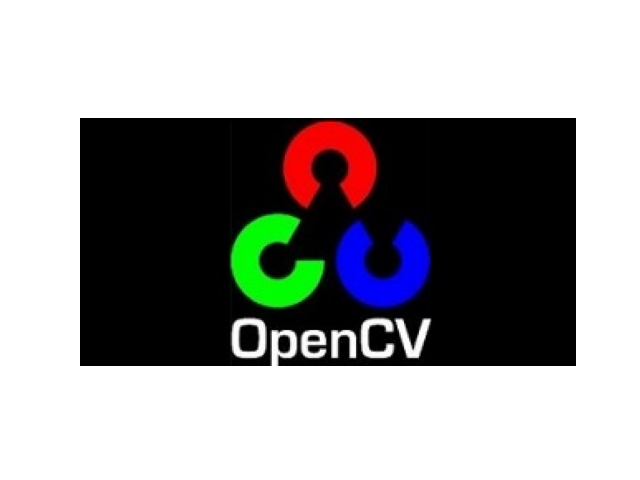

In [1]:
%matplotlib widget

import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets

alpha_slider_max = 100

src1 = cv2.imread('../images/class.vision.jpg')
src2 = cv2.imread('../images/opencv.jpg')

fig, ax = plt.subplots()
display_image = ax.imshow(cv2.cvtColor(src1, cv2.COLOR_BGR2RGB))
ax.axis('off')

def on_trackbar(val):
    alpha = val / alpha_slider_max
    beta = 1.0 - alpha
    dst = cv2.addWeighted(src1, alpha, src2, beta, 0.0)
    display_image.set_data(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
    fig.canvas.draw_idle()

slider = widgets.IntSlider(
    value=0, min=0, max=alpha_slider_max,
    description='Alpha'
)

widgets.interactive(on_trackbar, val=slider)

<div style="direction:rtl;text-align:right;font-family:Tahoma">
افزودن ثبت نتیجه در notebook</div>

IntSlider(value=0, description='Alpha')

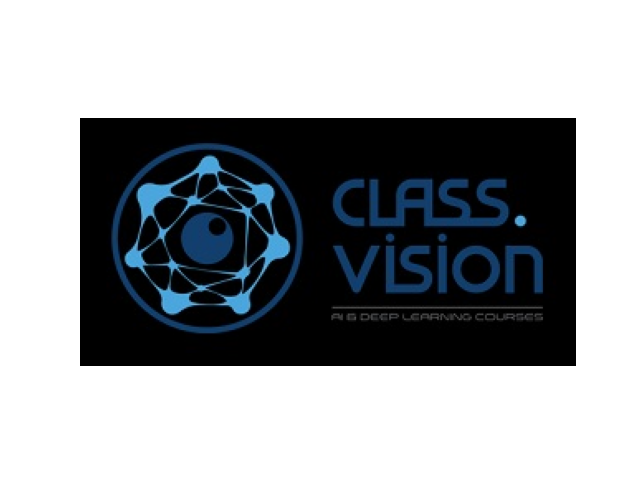

In [2]:
%matplotlib widget

import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets

alpha_slider_max = 100

src1 = cv2.imread('../images/class.vision.jpg')
src2 = cv2.imread('../images/opencv.jpg')

alpha = 0
dst = src1.copy()

fig, ax = plt.subplots()
display_image = ax.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
ax.axis('off')

def on_trackbar(val):
    global dst, alpha
    alpha = val / alpha_slider_max
    beta = 1.0 - alpha
    dst = cv2.addWeighted(src1, alpha, src2, beta, 0.0)
    display_image.set_data(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
    fig.canvas.draw_idle()

slider = widgets.IntSlider(
    value=0, min=0, max=alpha_slider_max,
    description='Alpha'
)

display(slider)
slider.observe(lambda change: on_trackbar(change['new']), names='value')

plt.show()

<div style="direction:rtl;text-align:right;font-family:Tahoma">
افزودن trackbar برای تغییر رنگ صفحه</div>

IntSlider(value=0, description='R', max=255)

IntSlider(value=0, description='G', max=255)

IntSlider(value=0, description='B', max=255)

ToggleButton(value=False, description='OFF')

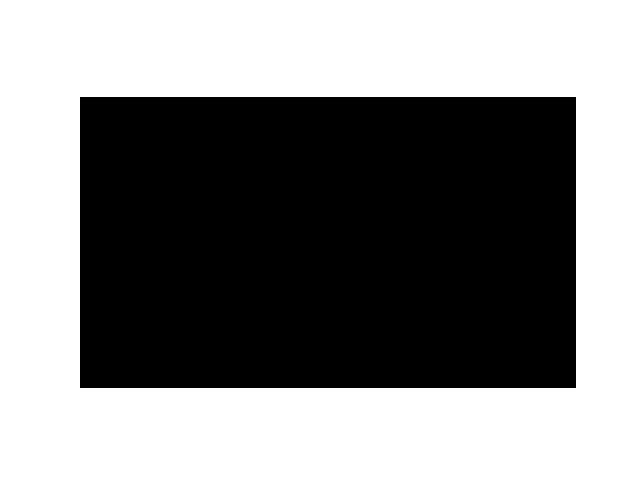

In [3]:
%matplotlib widget

import numpy as np
import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets

img = np.zeros((300, 512, 3), np.uint8)

fig, ax = plt.subplots()
display_image = ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax.axis('off')

R = widgets.IntSlider(description='R', min=0, max=255)
G = widgets.IntSlider(description='G', min=0, max=255)
B = widgets.IntSlider(description='B', min=0, max=255)

switch = widgets.ToggleButton(description='OFF', value=False)

def update(change=None):
    if switch.value:
        img[:] = [B.value, G.value, R.value]
        switch.description = 'ON'
    else:
        img[:] = 0
        switch.description = 'OFF'

    display_image.set_data(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    fig.canvas.draw_idle()

for slider in [R, G, B]:
    slider.observe(update, names='value')
switch.observe(update, names='value')

display(R, G, B, switch)
plt.show()

https://docs.opencv.org/3.4/da/d6a/tutorial_trackbar.html

https://docs.opencv.org/4.x/d9/dc8/tutorial_py_trackbar.html